<a href="https://colab.research.google.com/github/Danielgenez18/Curiso-2026/blob/main/Sustentaciones__Daniel_Genez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Formato para Trabajar en Colab 2026**
# **Teoria de Probabilidad**
## **DANIEL ALFONSO GENEZ MANJARRES**
> Email:dgenezm@gmail.com


# **Librerias para Trabajar en R**

In [18]:
# @title **Librerias para Trabajar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

<a name="inicio"></a>


## **1.** [ Ejemplo: Simulación de lanzar una moneda al aire y observar la cara de la moneda que mira hacia arriba al caer.](#T1)
## **2.** [ Experimento Aleatorio - Lanzamiento de un dado (6 caras)](#T2)

## **3.** [Experimento: Lanzamiento de una moneda](#T3)

## **4.** [Lanzamiento de un dado justo usando R](#T4)

## **5.** [Preferencias de helado](#T5)

## **6.** [Probabilidad Clásica](#T6)

## **7.** [Estimación de la probabilidad de obtener cara en una moneda (posiblemente sesgada)](#T7)


## **8.** [](#T8)

## **9.** [](#T9)


## **10.** [](#T10)

## **11.** [](#T11)

## **12.** [](#T12)

## **13.** [](#T13)

## **14.** [](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


## **18.** [](#T18)

## **19.** [](#T19)


## **20.** [](#T20)

## **21.** [](#T21)

## **22.** [](#T22)

## **23.** [](#T23)

## **24.** [](#T24)

## **25.** [](#T25)

## **26.** [](#T26)

## **27.** [](#T27)


## **28.** [](#T28)

## **29.** [](#T29)


## **30.** [](#T30)

## **31.** [](#T31)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Ejemplo: Simulación de lanzar una moneda al aire y observar la cara de la moneda que mira hacia arriba al caer. **


{'CARA': 0, 'SELLO': 0}


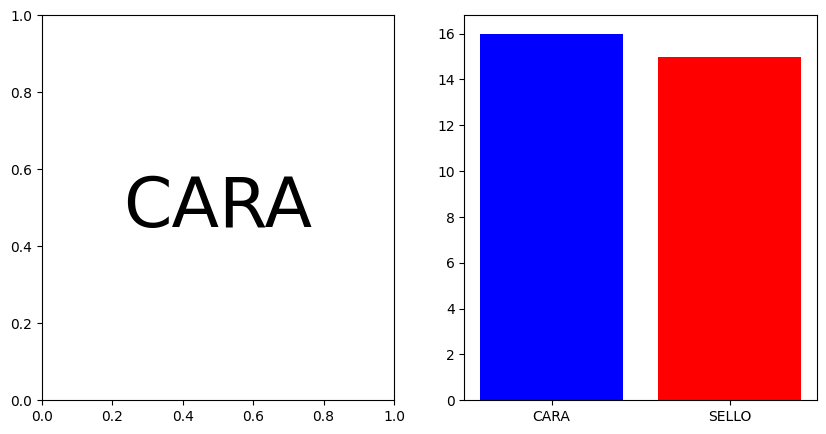

In [3]:
# @title **Lanzamiento de una moneda**
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

# Función para lanzar la moneda
def lanzar_moneda():
    return np.random.choice(['CARA', 'SELLO'])

# Inicialización de variables para contar los resultados
resultados = {'CARA': 0, 'SELLO': 0}

# Función para actualizar los resultados y el gráfico en cada fotograma de la animación
def actualizar(i):
    resultado = lanzar_moneda()
    resultados[resultado] += 1
    ejes[0].clear()
    ejes[0].text(0.5, 0.5, resultado, fontsize=50, ha='center', va='center')
    ejes[1].clear()
    ejes[1].bar(resultados.keys(), resultados.values(), color=['blue', 'red'])

# Configuración inicial del gráfico
fig, ejes = plt.subplots(1, 2, figsize=(10, 5))

# Configuración de la animación
ani = animation.FuncAnimation(fig, actualizar, frames=29, interval=333, repeat=False)
print(resultados)
# Muestra la animación en el notebook
HTML(ani.to_html5_video())

In [ ]:
%%R
install.packages(c("ggplot2", "gganimate", "gifski"))

library(ggplot2)
library(gganimate)

lanzamientos <- sample(c("CARA", "SELLO"), 19, replace = TRUE)

frames <- lapply(1:19, function(i) {
  conteo <- table(factor(lanzamientos[1:i], levels = c("CARA", "SELLO")))
  data.frame(
    resultado = names(conteo),
    frecuencia = as.integer(conteo),
    frame = i,
    ultimo = lanzamientos[i]
  )
})

df <- do.call(rbind, frames)

p <- ggplot(df, aes(x = resultado, y = frecuencia, fill = resultado)) +
  geom_bar(stat = "identity") +
  geom_text(aes(x = 1.5, y = max(df$frecuencia) / 2,
                label = ultimo), size = 14, inherit.aes = FALSE) +
  scale_fill_manual(values = c("CARA" = "blue", "SELLO" = "red")) +
  labs(title = "Lanzamiento {closest_state}", x = "", y = "Frecuencia") +
  theme_minimal() +
  transition_states(frame, transition_length = 1, state_length = 1)

anim_save("moneda.gif", animate(p, nframes = 19, fps = 2, width = 700, height = 400))

library(IRdisplay)
display_gif("moneda.gif")

[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Experimento Aleatorio - Lanzamiento de un dado (6 caras)**


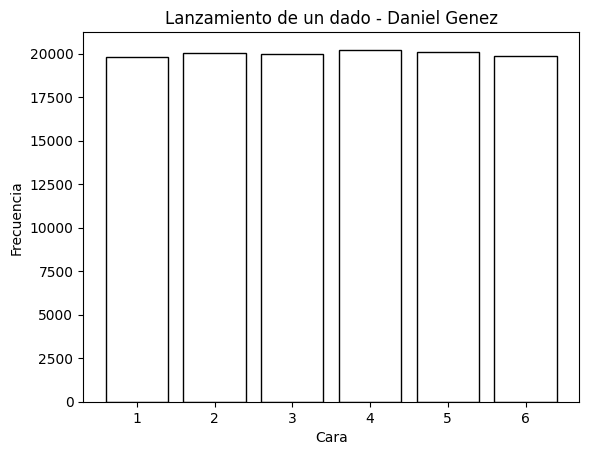

In [8]:
# @title **Lanzamiento de un dado**
import numpy as np
import matplotlib.pyplot as plt

# Simulación
n = 120000
resultados = np.random.randint(1, 7, size=n)

# Gráfico
plt.hist(resultados, bins=np.arange(0.5, 7.5, 1), rwidth=0.8, color="white", edgecolor="black")
plt.xticks(range(1, 7))
plt.title("Lanzamiento de un dado - Daniel Genez")
plt.xlabel("Cara")
plt.ylabel("Frecuencia")
plt.show()

✅ GIF guardado como 'dado_animacion.gif'
✅ GIF re-guardado con loop=1 (para en el último frame)


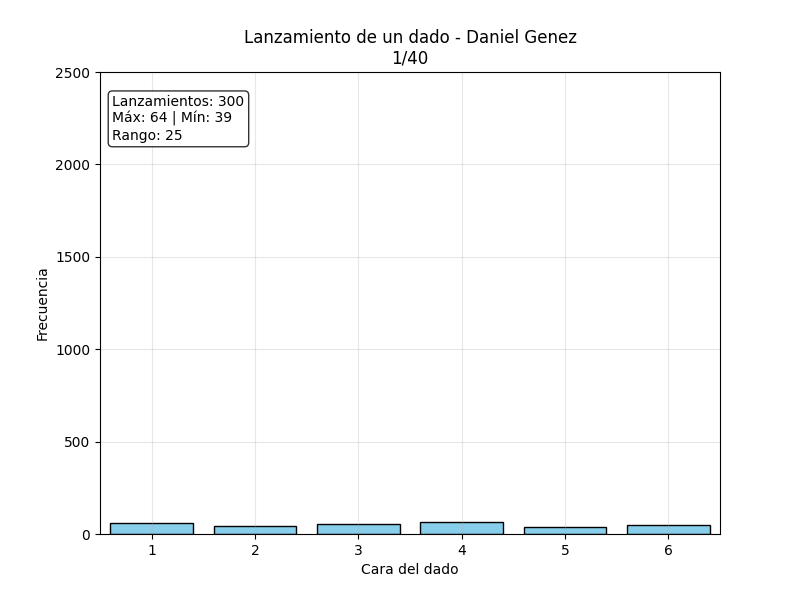

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image as PILImage, ImageSequence

# Configuración de la animación
n_total = 12000
intervalo = 50  # milisegundos entre frames
frames_guardar = 40  # número de frames en el GIF

# Pre-generamos todos los lanzamientos
np.random.seed(42)
todos_resultados = np.random.randint(1, 7, size=n_total)

# Configuración de la figura
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0.5, 6.5)
ax.set_ylim(0, 450)
ax.set_xticks(range(1, 7))
ax.set_xlabel("Cara del dado")
ax.set_ylabel("Frecuencia")
ax.set_title("Evolución del lanzamiento de un dado\nDaniel Genez")
ax.grid(True, alpha=0.3)

# Inicializar el histograma
n, bins, patches = ax.hist([], bins=np.arange(0.5, 7.5, 1),
                           rwidth=0.8, color="skyblue", edgecolor="black")

# Texto para mostrar el número de lanzamientos
texto_lanzamientos = ax.text(0.02, 0.95, '', transform=ax.transAxes,
                             fontsize=12, verticalalignment='top',
                             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

def update(frame):
    """Actualiza el histograma para cada frame"""
    n_lanzamientos = int((frame + 1) * n_total / frames_guardar)
    resultados_actuales = todos_resultados[:n_lanzamientos]

    ax.clear()
    ax.hist(resultados_actuales, bins=np.arange(0.5, 7.5, 1),
            rwidth=0.8, color="skyblue", edgecolor="black")
    ax.set_xlim(0.5, 6.5)
    ax.set_ylim(0, 2500)
    ax.set_xticks(range(1, 7))
    ax.set_xlabel("Cara del dado")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Lanzamiento de un dado - Daniel Genez\n{frame+1}/{frames_guardar}")
    ax.grid(True, alpha=0.3)

    if n_lanzamientos > 0:
        frecuencias = [np.sum(resultados_actuales == i) for i in range(1, 7)]
        max_freq = max(frecuencias)
        min_freq = min(frecuencias)
        texto = f"Lanzamientos: {n_lanzamientos}\n"
        texto += f"Máx: {max_freq} | Mín: {min_freq}\n"
        texto += f"Rango: {max_freq - min_freq}"
        ax.text(0.02, 0.95, texto, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    return patches

# Crear la animación
anim = FuncAnimation(fig, update, frames=frames_guardar,
                     interval=intervalo, repeat=False)

# Guardar como GIF
anim.save('dado_animacion.gif', writer=PillowWriter(fps=20))
plt.close()
print("✅ GIF guardado como 'dado_animacion.gif'")

# ── Post-procesar: forzar loop=1 (se reproduce una vez y para) ──
img = PILImage.open('dado_animacion.gif')
frames = [frame.copy() for frame in ImageSequence.Iterator(img)]

frames[0].save(
    'dado_animacion.gif',
    save_all=True,
    append_images=frames[1:],
    loop=1,           # 0 = infinito | 1 = una vez y para
    duration=1000//20  # 50ms por frame = 20fps
)
print("✅ GIF re-guardado con loop=1 (para en el último frame)")

# Mostrar en Jupyter
from IPython.display import Image as IPImage
IPImage(filename='dado_animacion.gif')

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Experimento: Lanzamiento de una moneda**


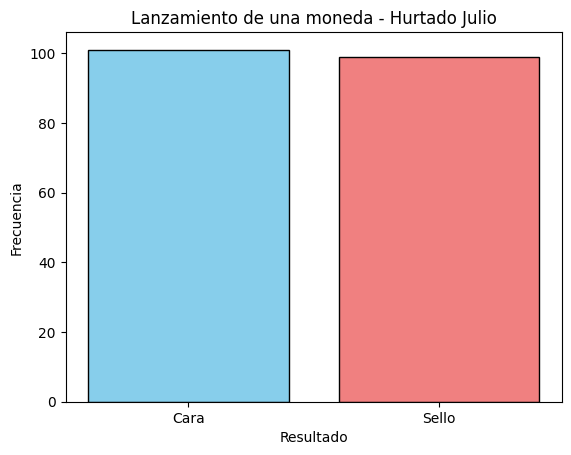

In [16]:
resultados = np.random.choice(["Cara", "Sello"], size=200)

# Count the occurrences of each outcome
counts = np.unique(resultados, return_counts=True)
outcomes = counts[0]
frequencies = counts[1]

# Create a bar plot
plt.bar(outcomes, frequencies, color=["skyblue", "lightcoral"], edgecolor="black")
plt.title("Lanzamiento de una moneda - Hurtado Julio")
plt.xlabel("Resultado")
plt.ylabel("Frecuencia")
plt.show()

Generando animación...
✅ GIF guardado como 'moneda_animacion.gif'

📊 Estadísticas finales:
Total lanzamientos: 2000
Cara: 1016 veces
Sello: 984 veces
Diferencia: 32


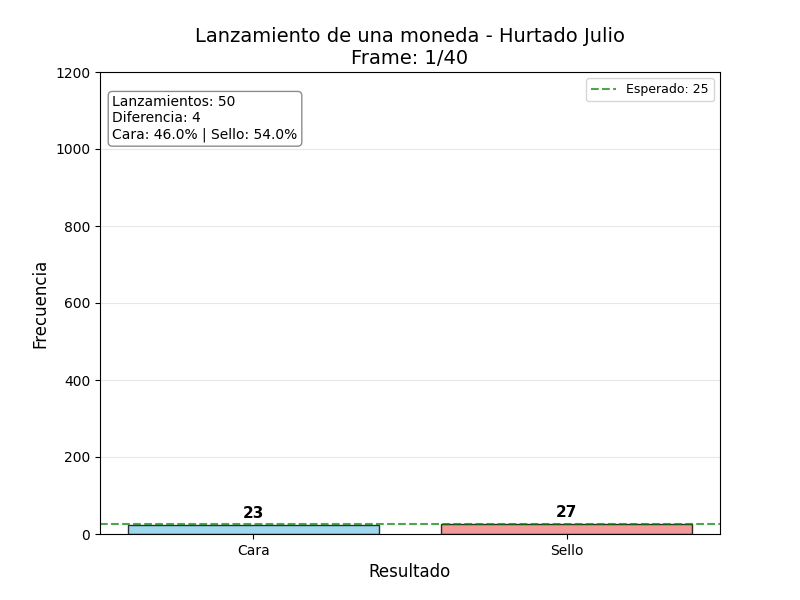

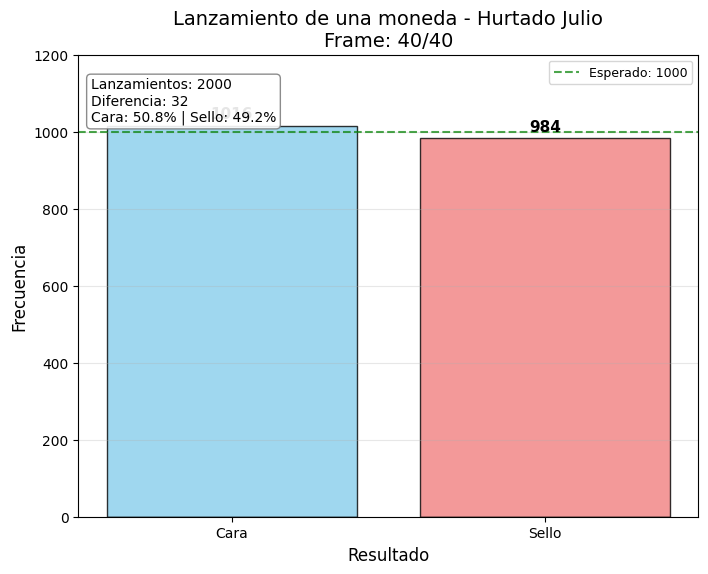

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Configuración de la animación
n_total = 2000
intervalo = 50  # milisegundos entre frames
frames_guardar = 40  # número de frames en el GIF

# Pre-generamos todos los lanzamientos
np.random.seed(42)  # para reproducibilidad
todos_resultados = np.random.choice(["Cara", "Sello"], size=n_total)

# Configuración de la figura
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_ylim(0, 1200)
ax.set_ylabel("Frecuencia")
ax.set_title("Evolución del lanzamiento de una moneda\nHurtado Julio")
ax.grid(True, alpha=0.3, axis='y')

# Colores para Cara y Sello
colores = ["skyblue", "lightcoral"]

# Función para inicializar
def init():
    ax.bar(["Cara", "Sello"], [0, 0], color=colores, edgecolor="black")
    ax.set_xlabel("Resultado")
    ax.set_ylabel("Frecuencia")
    return []

# Función de actualización para cada frame
def update(frame):
    """Actualiza el gráfico de barras para cada frame"""
    # Número de lanzamientos para este frame
    n_lanzamientos = int((frame + 1) * n_total / frames_guardar)

    # Obtener los resultados hasta este momento
    resultados_actuales = todos_resultados[:n_lanzamientos]

    # Limpiar el eje
    ax.clear()

    # Calcular frecuencias
    conteos = {outcome: np.sum(resultados_actuales == outcome) for outcome in ["Cara", "Sello"]}

    # Crear gráfico de barras
    barras = ax.bar(conteos.keys(), conteos.values(),
                    color=colores, edgecolor="black", alpha=0.8)

    # Configurar el gráfico
    ax.set_ylim(0, max(1200, max(conteos.values()) * 1.1))
    ax.set_xlabel("Resultado", fontsize=12)
    ax.set_ylabel("Frecuencia", fontsize=12)
    ax.set_title(f"Lanzamiento de una moneda - Hurtado Julio\nFrame: {frame+1}/{frames_guardar}", fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')

    # Agregar valores sobre las barras
    for i, (outcome, freq) in enumerate(conteos.items()):
        ax.text(i, freq + 10, str(freq), ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Mostrar estadísticas en el gráfico
    if n_lanzamientos > 0:
        diferencia = abs(conteos["Cara"] - conteos["Sello"])
        porcentaje_cara = (conteos["Cara"] / n_lanzamientos) * 100
        porcentaje_sello = (conteos["Sello"] / n_lanzamientos) * 100

        texto = f"Lanzamientos: {n_lanzamientos}\n"
        texto += f"Diferencia: {diferencia}\n"
        texto += f"Cara: {porcentaje_cara:.1f}% | Sello: {porcentaje_sello:.1f}%"

        ax.text(0.02, 0.95, texto, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Mostrar línea del valor esperado (1000 para 2000 lanzamientos)
    if n_lanzamientos > 0:
        esperado = n_lanzamientos / 2
        ax.axhline(y=esperado, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Esperado: {esperado:.0f}')
        ax.legend(loc='upper right', fontsize=9)

    return barras

# Crear la animación
print("Generando animación...")
anim = FuncAnimation(fig, update, frames=frames_guardar,
                    init_func=init, interval=intervalo, repeat=True)

# Guardar como GIF
anim.save('moneda_animacion.gif', writer=PillowWriter(fps=20))
print("✅ GIF guardado como 'moneda_animacion.gif'")

# Mostrar estadísticas finales
print("\n📊 Estadísticas finales:")
print(f"Total lanzamientos: {n_total}")
print(f"Cara: {np.sum(todos_resultados == 'Cara')} veces")
print(f"Sello: {np.sum(todos_resultados == 'Sello')} veces")
print(f"Diferencia: {abs(np.sum(todos_resultados == 'Cara') - np.sum(todos_resultados == 'Sello'))}")

# Si estás en Jupyter notebook, puedes mostrar el GIF con:
from IPython.display import Image
Image(filename='moneda_animacion.gif')

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Lanzamiento de un dado justo usando R**


In [20]:
%%R
# @title **Espacio muestral para el lanzamiento e un dado $$\Omega = \{1,2,3,4,5,6\}$$**
# Espacio muestral
omega <- 1:6

# Eventos
A <- c(2, 4, 6)
B <- c(4, 5, 6)
C <- c(2, 3, 5)

# a) Unión de A y B
union_AB <- union(A, B)
cat("Unión de A y B:", union_AB, "\n")

# b) Intersección de A y B
interseccion_AB <- intersect(A, B)
cat("Intersección de A y B:", interseccion_AB, "\n")

# c) Complemento de A
complemento_A <- setdiff(omega, A)
cat("Complemento de A:", complemento_A, "\n")

# d) Diferencia de B y C
diferencia_BC <- setdiff(B, C)
cat("Diferencia de B y C:", diferencia_BC, "\n")

Unión de A y B: 2 4 6 5 
Intersección de A y B: 4 6 
Complemento de A: 1 3 5 
Diferencia de B y C: 4 6 


[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Preferencias de helado**




In [23]:
%%R
# Total de personas
total_personas <- 100

# Número de personas por preferencia
n_chocolate <- 60
n_vainilla <- 50
n_ambos <- 30

# a) Unión (chocolate o vainilla)
n_union_CV <- n_chocolate + n_vainilla - n_ambos
cat("Chocolate o vainilla:", n_union_CV, "\n")

# b) Solo chocolate
n_solo_chocolate <- n_chocolate - n_ambos
cat("Solo chocolate:", n_solo_chocolate, "\n")

# c) No prefieren chocolate
n_no_chocolate <- total_personas - n_chocolate
cat("No prefieren chocolate:", n_no_chocolate, "\n")

Chocolate o vainilla: 80 
Solo chocolate: 30 
No prefieren chocolate: 40 


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Probabilidad Clásica**


In [25]:
%%R
# @title **Espacio muestral del dado**
# Espacio muestral del dado
espacio_muestral_dado <- 1:6
total_resultados_dado <- length(espacio_muestral_dado)

# Probabilidad de obtener un número par
resultados_par <- c(2, 4, 6)
resultados_favorables_par <- length(resultados_par)
prob_par <- resultados_favorables_par / total_resultados_dado
cat("Probabilidad de obtener un número par:", prob_par, "\n")

# Probabilidad de obtener un número mayor que 4
resultados_mayor_4 <- c(5, 6)
resultados_favorables_mayor_4 <- length(resultados_mayor_4)
prob_mayor_4 <- resultados_favorables_mayor_4 / total_resultados_dado
cat("Probabilidad de obtener un número mayor que 4:", prob_mayor_4, "\n")

Probabilidad de obtener un número par: 0.5 
Probabilidad de obtener un número mayor que 4: 0.3333333 


In [31]:
%%R
# @title **Espacio muestral de los digitos**
# Espacio muestral del dado
espacio_muestral_digitos <- 0:9
total_resultados_primo <- length(espacio_muestral_digitos)

# Probabilidad de obtener un número par
resultados_primo <- c(2,3,5,7)
resultados_favorables_primo <- length(resultados_primo)
prob_primo <- resultados_favorables_primo / total_resultados_primo
cat("Probabilidad de obtener un número primo:", prob_primo, "\n")

Probabilidad de obtener un número primo: 0.4 


✅ GIF guardado: 'primos_barras.gif'


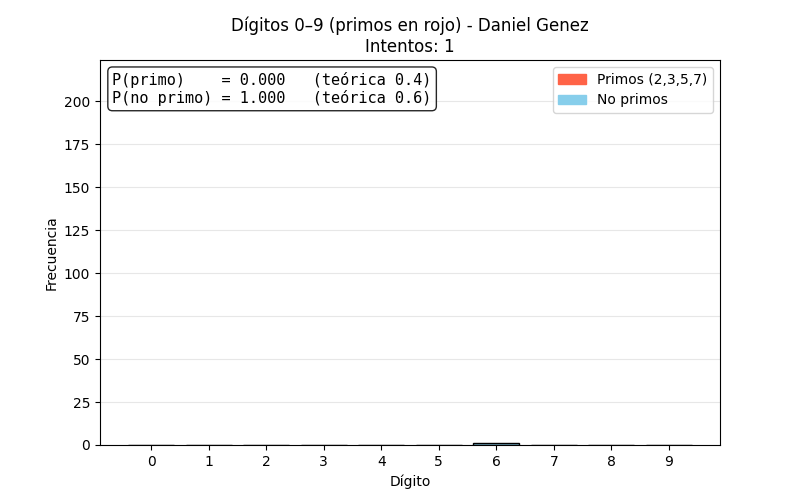

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image as PILImage, ImageSequence

# ── Configuración ──
np.random.seed(42)
espacio = np.arange(0, 10)
primos  = np.array([2, 3, 5, 7])

prob_teo_primo    = len(primos) / len(espacio)        # 0.4
prob_teo_noprimo  = 1 - prob_teo_primo                # 0.6

n_total, n_frames = 2000, 50
lanzamientos = np.random.randint(0, 10, size=n_total)
cortes  = np.linspace(1, n_total, n_frames, dtype=int)
colores = ['tomato' if d in primos else 'skyblue' for d in espacio]
ymax    = max(np.bincount(lanzamientos, minlength=10))

fig, ax = plt.subplots(figsize=(8, 5))

def update(frame):
    n   = cortes[frame]
    sub = lanzamientos[:n]
    conteo = np.bincount(sub, minlength=10)

    # Probabilidades empíricas
    p_primo   = np.mean(np.isin(sub, primos))
    p_noprimo = 1 - p_primo

    ax.clear()
    ax.bar(espacio, conteo, color=colores, edgecolor='black')
    ax.set_xticks(espacio)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Dígito")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Dígitos 0–9 (primos en rojo) - Daniel Genez\nIntentos: {n}")
    ax.grid(True, axis='y', alpha=0.3)

    # ── Cuadro de texto con las probabilidades ──
    texto = (f"P(primo)    = {p_primo:.3f}   (teórica 0.4)\n"
             f"P(no primo) = {p_noprimo:.3f}   (teórica 0.6)")
    ax.text(0.02, 0.97, texto, transform=ax.transAxes,
            fontsize=11, va='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    # Leyenda de colores
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='tomato', label='Primos (2,3,5,7)'),
                       Patch(color='skyblue', label='No primos')],
              loc='upper right')
    return ax.patches

# ── Crear y guardar ──
anim = FuncAnimation(fig, update, frames=n_frames, interval=100, repeat=False)
anim.save('primos_barras.gif', writer=PillowWriter(fps=10))
plt.close()

# loop=1 (una vez y para)
img = PILImage.open('primos_barras.gif')
frames = [f.copy() for f in ImageSequence.Iterator(img)]
frames[0].save('primos_barras.gif', save_all=True,
               append_images=frames[1:], loop=1, duration=100)
print("✅ GIF guardado: 'primos_barras.gif'")

from IPython.display import Image as IPImage
IPImage(filename='primos_barras.gif')

✅ GIF guardado como 'primos_animacion.gif'
✅ GIF re-guardado con loop=1 (para en el último frame)


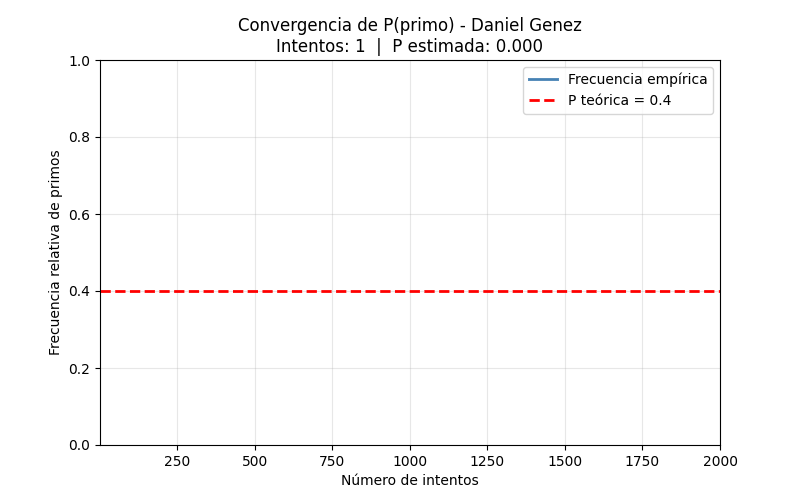

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image as PILImage, ImageSequence

# ── Configuración ──
np.random.seed(42)
espacio_muestral = np.arange(0, 10)         # dígitos 0–9
primos           = np.array([2, 3, 5, 7])
prob_teorica     = len(primos) / len(espacio_muestral)   # = 0.4

n_total  = 2000      # número total de intentos
n_frames = 50        # frames del GIF

# ── Pre-generar lanzamientos y frecuencia acumulada ──
lanzamientos = np.random.randint(0, 10, size=n_total)
es_primo     = np.isin(lanzamientos, primos)             # True/False
prob_acum    = np.cumsum(es_primo) / np.arange(1, n_total + 1)

# Puntos (nº de intentos) donde se captura cada frame
cortes = np.linspace(1, n_total, n_frames, dtype=int)

# ── Figura ──
fig, ax = plt.subplots(figsize=(8, 5))

def update(frame):
    n = cortes[frame]
    x = np.arange(1, n + 1)
    y = prob_acum[:n]
    p = y[-1]

    ax.clear()
    ax.plot(x, y, lw=2, color="steelblue", label="Frecuencia empírica")
    ax.axhline(prob_teorica, color="red", ls="--", lw=2,
               label=f"P teórica = {prob_teorica:.1f}")
    ax.set_xlim(1, n_total)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Número de intentos")
    ax.set_ylabel("Frecuencia relativa de primos")
    ax.set_title(f"Convergencia de P(primo) - Daniel Genez\n"
                 f"Intentos: {n}  |  P estimada: {p:.3f}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    return ax.lines

# ── Crear y guardar la animación ──
anim = FuncAnimation(fig, update, frames=n_frames, interval=100, repeat=False)
anim.save('primos_animacion.gif', writer=PillowWriter(fps=10))
plt.close()
print("✅ GIF guardado como 'primos_animacion.gif'")

# ── Post-procesar: forzar loop=1 (una vez y para) ──
img = PILImage.open('primos_animacion.gif')
frames = [f.copy() for f in ImageSequence.Iterator(img)]
frames[0].save('primos_animacion.gif', save_all=True,
               append_images=frames[1:], loop=1, duration=100)
print("✅ GIF re-guardado con loop=1 (para en el último frame)")

# ── Mostrar en Jupyter ──
from IPython.display import Image as IPImage
IPImage(filename='primos_animacion.gif')

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Estimación de la probabilidad de obtener cara en una moneda (posiblemente sesgada)**




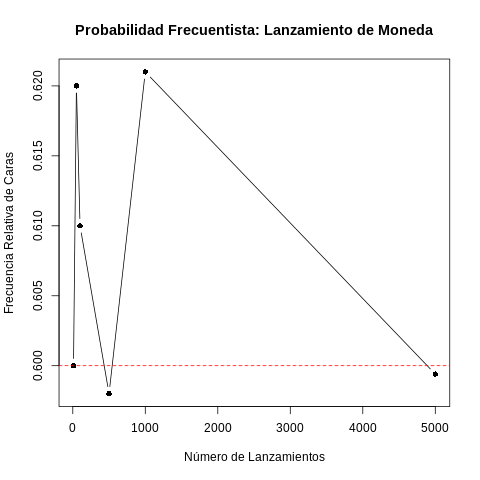

In [32]:
%%R
# Probabilidad verdadera de cara (desconocida para el experimentador)
prob_verdadera_cara <- 0.6

# Número de lanzamientos en cada etapa
n_lanzamientos <- c(10, 50, 100, 500, 1000, 5000)
frecuencias_relativas_cara <- numeric(length(n_lanzamientos))

set.seed(123) # Para reproducibilidad

for (i in 1:length(n_lanzamientos)) {
  lanzamientos <- rbinom(n_lanzamientos[i], 1, prob_verdadera_cara) # 1 = cara, 0 = cruz
  frecuencias_relativas_cara[i] <- mean(lanzamientos)
}

# Visualización de la convergencia
plot(n_lanzamientos, frecuencias_relativas_cara, type = "b", pch = 16,
     xlab = "Número de Lanzamientos", ylab = "Frecuencia Relativa de Caras",
     main = "Probabilidad Frecuentista: Lanzamiento de Moneda")
abline(h = prob_verdadera_cara, col = "red", lty = 2)

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. **


[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. **


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. **




[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. **


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. **


[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. **


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. **


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **15. **




[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **


[⬆️ Volver al inicio](#inicio)

<a name="T17"></a>
## **17. **




[⬆️ Volver al inicio](#inicio)

<a name="T18"></a>
## **18. **


[⬆️ Volver al inicio](#inicio)

<a name="T19"></a>
## **19. **


[⬆️ Volver al inicio](#inicio)

<a name="T20"></a>
## **20. **




[⬆️ Volver al inicio](#inicio)

<a name="T21"></a>
## **21. **


[⬆️ Volver al inicio](#inicio)

<a name="T22"></a>
## **22. **


[⬆️ Volver al inicio](#inicio)

<a name="T23"></a>
## **23. **


[⬆️ Volver al inicio](#inicio)

<a name="T24"></a>
## **24. **


[⬆️ Volver al inicio](#inicio)

<a name="T25"></a>
## **25. **




[⬆️ Volver al inicio](#inicio)

<a name="T26"></a>
## **26. **


[⬆️ Volver al inicio](#inicio)

<a name="T27"></a>
## **27. **




[⬆️ Volver al inicio](#inicio)

<a name="T28"></a>
## **28. **


[⬆️ Volver al inicio](#inicio)

<a name="T29"></a>
## **29. **


[⬆️ Volver al inicio](#inicio)

<a name="T30"></a>
## **30. **




[⬆️ Volver al inicio](#inicio)


## **ULTIMO**
[⬆️ Volver al ULTIMO](#ULTIMO)


<a name="ULTIMO"></a>

[⬆️ Volver al inicio](#inicio)

ULTIMO